<a href="https://colab.research.google.com/github/zkagda/stars_solver/blob/main/Stars_solver.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# !pip install pulp

from pulp import *
import numpy as np

def solve_grid_ilp(n: int, m: int, regions: list[set], stars: int) -> np.ndarray | None:
    """
    Solve the binary grid ILP problem.

    Parameters
    ----------
    n        : int         – number of rows    (indices 0 … n-1)
    m        : int         – number of columns (indices 0 … m-1)
    regions  : list[set]   – S', each element is a set of (i,j) tuples
                             e.g. [ {(1,2),(1,1),(2,3)}, {(3,4),(3,5)} ]

    Returns
    -------
    solution : np.ndarray of shape (n, m) with the binary solution,
               or None if the problem is infeasible / unbounded.
    """

    # ── 1. Create the problem ─────────────────────────────────────────────────
    prob = LpProblem("Grid_ILP", LpMinimize)

    # ── 2. Decision variables  x[i][j] ∈ {0, 1} ──────────────────────────────
    x = [[LpVariable(f"x_{i}_{j}", cat="Binary")
          for j in range(m)]
         for i in range(n)]

    # ── 3. Objective : min(0)  (feasibility problem) ──────────────────────────
    prob += 0

    # ── 4. Constraint (5) – boundary rows & columns must all be 0 ────────────
    # First and last rows
    for j in range(m):
        prob += x[0][j]   == 0, f"border_row_first_{j}"
        prob += x[n-1][j] == 0, f"border_row_last_{j}"
    # First and last columns  (corners already covered above, no harm repeating)
    for i in range(n):
        prob += x[i][0]   == 0, f"border_col_first_{i}"
        prob += x[i][m-1] == 0, f"border_col_last_{i}"

    # ── 5. Constraint (1) – interior row sums = 1 ────────────────────────────
    # For every interior row i (1 … n-2), sum over interior columns (1 … m-2)
    for i in range(1, n - 1):
        prob += (
            lpSum(x[i][j] for j in range(1, m - 1)) == stars,
            f"row_sum_{i}"
        )

    # ── 6. Constraint (2) – interior column sums = 1 ─────────────────────────
    # For every interior column j (1 … m-2), sum over interior rows (1 … n-2)
    for j in range(1, m - 1):
        prob += (
            lpSum(x[i][j] for i in range(1, n - 1)) == stars,
            f"col_sum_{j}"
        )

    # Constraint (3) UPDATED — if x_ij = 1, all 8 neighbours must be 0
    # Equivalent to: x_ij + x_kl <= 1 for all neighbours (k,l) of (i,j)
    for i in range(1, n - 1):
        for j in range(1, m - 1):
            for k in range(i - 1, i + 2):       # i-1, i, i+1
                for l in range(j - 1, j + 2):   # j-1, j, j+1
                    if (k, l) == (i, j):         # skip the cell itself
                        continue
                    if 0 <= k < n and 0 <= l < m:
                        prob += (
                            x[i][j] + x[k][l] <= 1,
                            f"neighbour_{i}_{j}_{k}_{l}"
                        )

    # ── 8. Constraint (4) – each region in S' sums to 1 ──────────────────────
    for idx, S in enumerate(regions):
        prob += (
            lpSum(x[i][j] for (i, j) in S) == stars,
            f"region_{idx}"
        )

    # ── 9. Solve ──────────────────────────────────────────────────────────────
    status = prob.solve(PULP_CBC_CMD(msg=0))   # msg=0 silences solver output

    print(f"Status: {LpStatus[prob.status]}")

    if LpStatus[prob.status] != "Optimal":
        print("No feasible solution found.")
        return None

    # ── 10. Extract and return the solution matrix ────────────────────────────
    solution = np.array([[int(value(x[i][j])) for j in range(m)]
                          for i in range(n)])

    return solution


# ═══════════════════════════════════════════════════════════════════════════════
# Example usage
# ═══════════════════════════════════════════════════════════════════════════════
if __name__ == "__main__":
    n = 7   # rows    (indices 0-4)
    m =7       # columns (indices 0-4)

    stars=2
    # example regions
    # regions = [{(1,1), (1,2), (1,3), (2,1), (2,2), (2,3), (3,1), (3,2), (4,1), (5,1), (6,1), (7,1), (8,1), (9,1), (5,2), (6,2), (7,2), (8,2), (9,2), (6,3), (7,3), (8,3), (9,3), (7,4), (8,4), (9,4)},
    #            {(1,4), (1,5), (2,4), (3,3), (3,4), (4,3)},
    #            {(1,6), (2,5), (2,6), (3,5), (3,6), (4,5), (4,6), (5,5), (5,6)},
    #            {(1,7), (1,8), (2,7), (2,8), (3,7), (3,8)},
    #            {(1,9), (2,9), (3,9), (4,9), (5,8), (5,9), (6,8), (6,9), (7,9), (8,9), (9,9)},
    #            {(4,2), (5,2), (5,3), (5,4), (6,4)},
    #            {(4,7), (4,8), (5,7), (6,6), (6,7), (6,8)},
    #            {(6,5), (7,5), (7,6), (8,5), (8,6), (9,5), (9,6), (9,4)},
    #            {(7,7), (7,8), (8,7), (8,8), (9,7)}]

    regions = [{(1,1)},
               {(1,2),(1,3),(1,4),(1,5),(2,4)},
               {(2,3),(3,2)},
               {(2,1),(3,1),(4,1),(5,1),(4,2),(5,2),(2,3),(3,3),(4,3),(5,3),(3,4),(3,5),(2,5),(3,5),(5,5)},
                {(4,4),(4,5)}]

    sol = solve_grid_ilp(n, m, regions, 1)

    if sol is not None:
        print("\nSolution grid (1 = selected):")
        print(sol)

Status: Optimal

Solution grid (1 = selected):
[[0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0]
 [0 0 0 0 1 0 0]
 [0 0 1 0 0 0 0]
 [0 0 0 0 0 1 0]
 [0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0]]


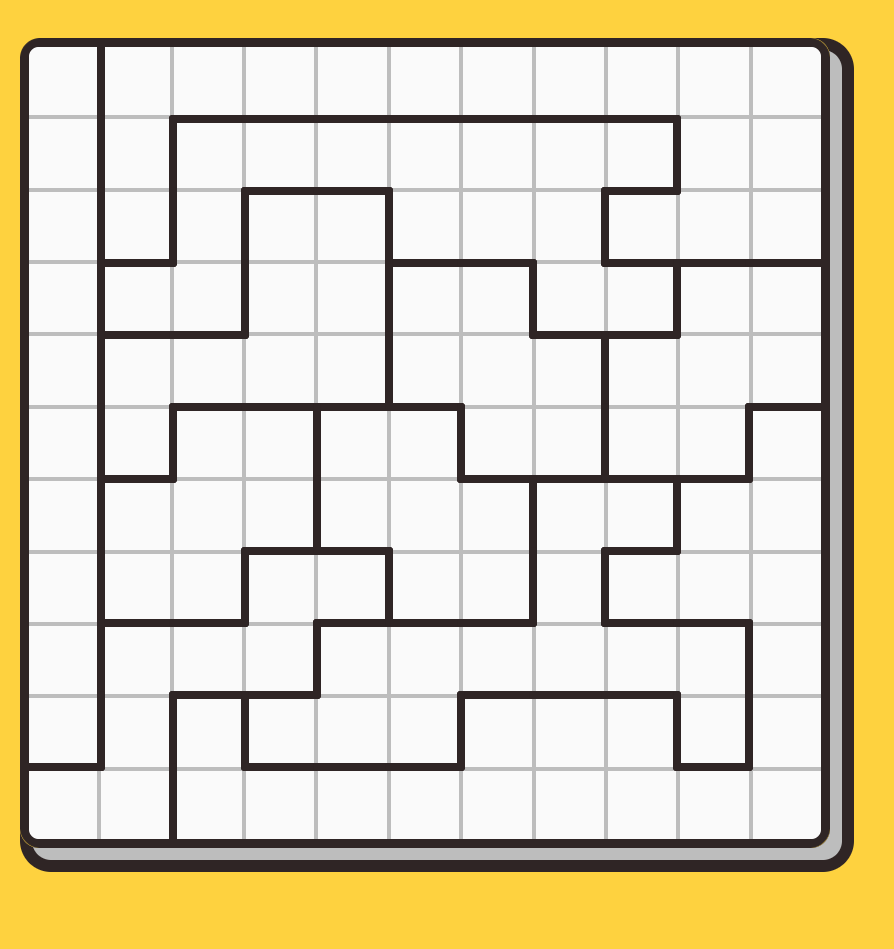

In [ ]:

    # n = 13  # rows    (indices 0-4)
    # m = 13       # columns (indices 0-4)

    # stars=2
    # regions = [{(x,y) for x in range(1,11) and y==1},
    #            {(x,y) for x==1 and y in range(2,12)} | {(2,2), (3,2),(2,10),(2,11),(3,9),(3,10),(3,11)},
    #            {(x,y) for x==2 and y in range(3,10)}| {(3,3),(3,6),(3,7),(3,8),(4,2),(4,3),(4,8),(4,9)},
    #            {(x,y) for x in range(3,6) and y in range(4,6)}| {(5,2),(5,3),(6,2)},
    #            {(x,y) for x in range(4,7) and y in range(6,9) if ((x,y)!= (4,8) and (x,y)!=(6,6))},
    #            {(x,y) for x in range(4,7) and y in range(9,12) if ((x,y)!= (4,9) and (x,y)!= (6,11))},
    #            {(x,y) for x in range(4,7) and y in range(9,12) if ((x,y)!= (4,9) and (x,y)!= (6,11))}

    # ]
    # sol = solve_grid_ilp(n, m, regions, stars)



    # if sol is not None:
    #     print("\nSolution grid (1 = selected):")
    #     print(sol)

In [ ]:
list= {(1,y) for y in range(2,12)} | {(2,3),(2,3)}
print(list)

{(1, 2), (1, 5), (1, 11), (1, 8), (1, 4), (2, 3), (1, 7), (1, 10), (1, 6), (1, 3), (1, 9)}


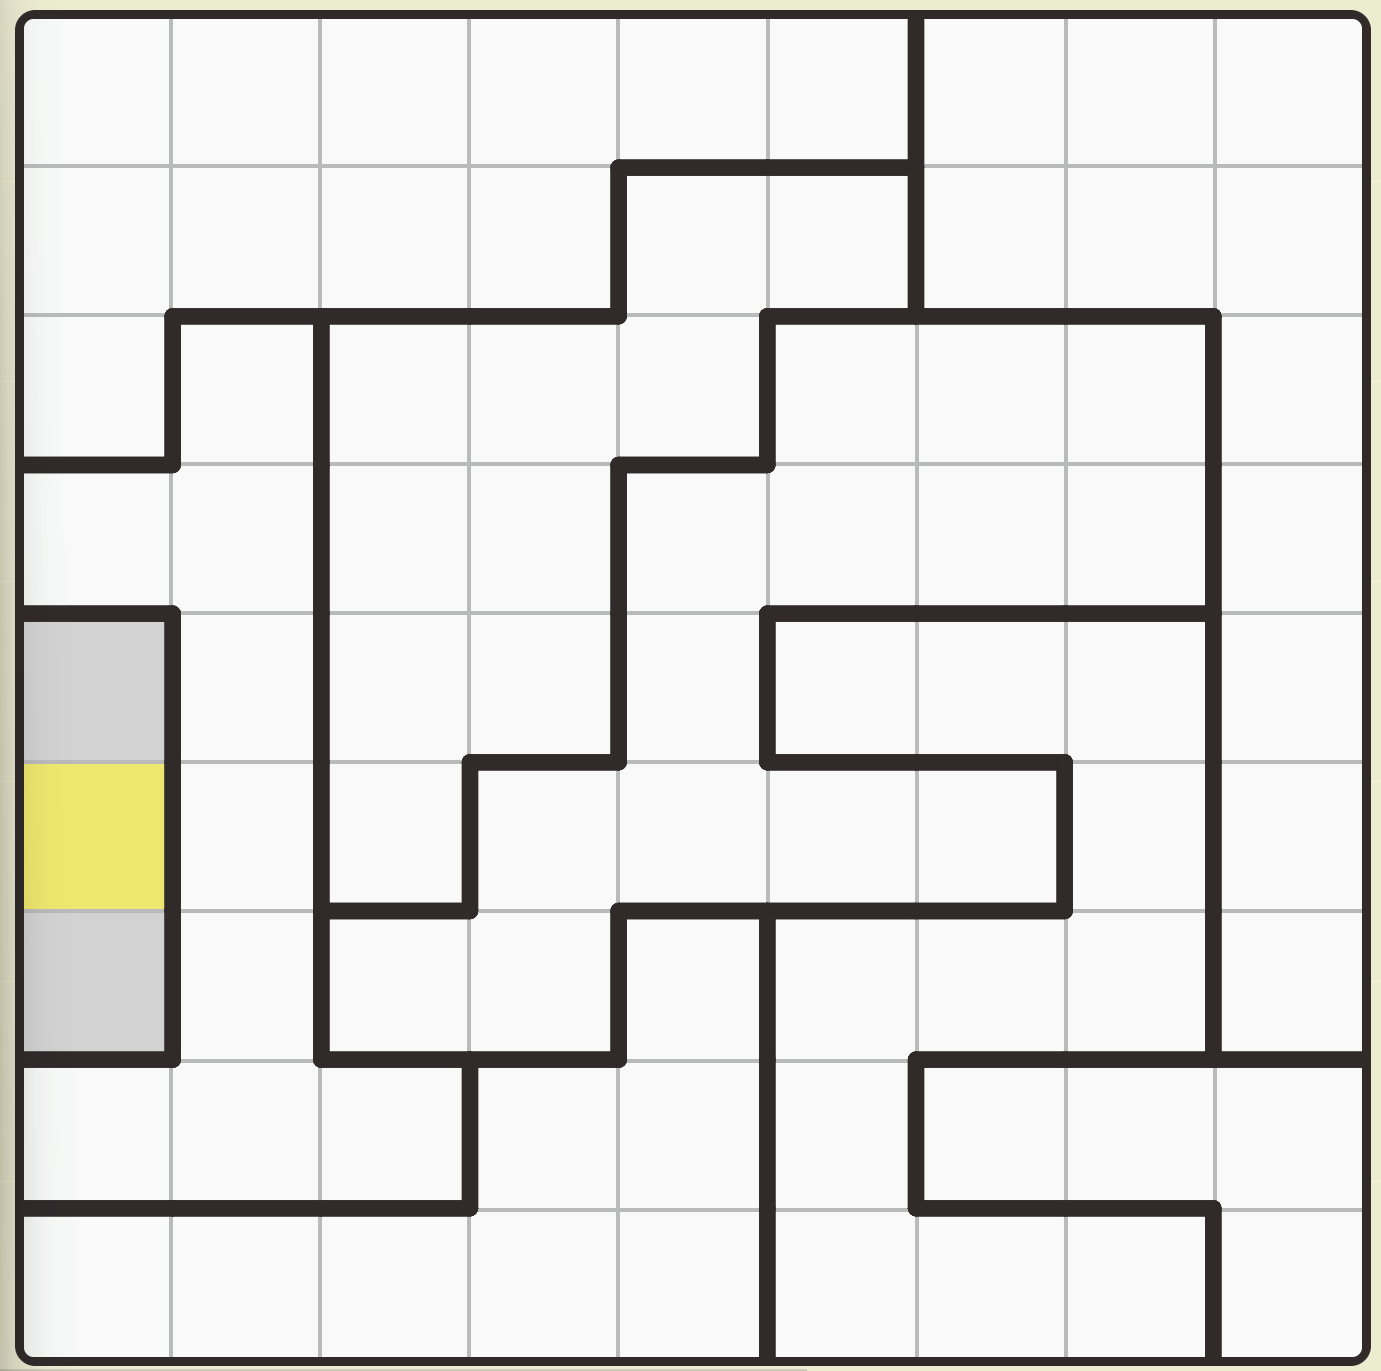

In [ ]:
regions_1= [{(1,1),(1,2),(1,3),(1,4),(1,5),(1,6),(2,1),(2,2),(2,3),(2,4),(3,1)},
 {(5,1),(6,1),(7,1)},
 {(4,1),(4,2),(3,2),(5,2),(6,2),(7,2),(8,2),(8,1),(8,3)},
 {(9,1),(9,2),(9,3),(9,4),(9,5),(8,4),(8,5),(7,5)},
 {(2,5),(2,6),(3,3),(3,4),(3,5),(4,3),(4,4),(5,3),(5,4),(6,3)},
 {(1,7),(1,8),(1,9),(2,7),(2,8),(2,9),(3,9),(4,9),(5,9),(6,9),(7,9)},
 {(3,6),(3,7),(3,8),(4,5),(4,6),(4,7),(4,8),(5,5),(6,4),(6,5),(6,6),(6,7),(7,3),(7,4)},
 {(5,6),(5,7),(5,8),(6,8),(7,8),(7,7),(7,6),(8,6),(9,6),(9,7),(9,8)},
 {(8,7),(8,8),(8,9),(9,9)}]

sum=0
for set in regions_1:
  sum+=len(set)
  # print(len(set))

# print(sum)


chars = ["a", "b", "c", "d", "e", "f", "g", "h", "i"]

grid= [["t" for x in range(9)] for y in range(9)]

i=0
for set in regions_1:
  # print(set)
  for id in set:
    # print(id[1]-1,id[0]-1)
    grid[id[0]-1][id[1]-1]= chars[i]
  i+=1


for row in grid:
    for item in row:
        # Use a tab separator and suppress the default newline
        print(f"{item} ", end='')
    # Print a newline character after each row is complete
    print()



a a a a a a f f f 
a a a a e e f f f 
a c e e e g g g f 
c c e e g g g g f 
b c e e g h h h f 
b c e g g g g h f 
b c g g d h h h f 
c c c d d h i i i 
d d d d d h h h i 


In [ ]:
n = 11  # rows    (indices 0-4)
m = 11       # columns (indices 0-4)

stars = 2

sol = solve_grid_ilp(n, m, regions_1, stars)



if sol is not None:
    print("\nSolution grid (1 = selected):")
    print(sol)

Status: Optimal

Solution grid (1 = selected):
[[0 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 1 0 0 0]
 [0 0 0 0 1 0 0 0 0 1 0]
 [0 0 1 0 0 0 1 0 0 0 0]
 [0 0 0 0 1 0 0 0 1 0 0]
 [0 1 0 0 0 0 1 0 0 0 0]
 [0 0 0 1 0 0 0 0 1 0 0]
 [0 1 0 0 0 1 0 0 0 0 0]
 [0 0 0 1 0 0 0 1 0 0 0]
 [0 0 0 0 0 1 0 0 0 1 0]
 [0 0 0 0 0 0 0 0 0 0 0]]


In [ ]:
#hard code regions and check

#region1
x_1 = {(1,x) for x in range(7)}
x_1 = x_1 | {(2,x) for x in range(1,7)}
x_1 = x_1 | {(3,x) for x in range(1,4)}
x_1 = x_1 | {(4,x) for x in range(2,5)}

#region2
x_2={(4,1)} | {(5,x) for x in range(1,4)} | {(6,x) for x in range(2,4)} | {(7,x) for x in range(2,5)}

#region3
x_3 = {(x,1) for x in range(6,11)}

#region 4
x_4 = {(8,x) for x in range(2,6)} | {(9,x) for x in range(2,4)} | {(10,x) for x in range(2,4)}

#region 5
x_5 = {(1,x) for x in range(7,11)} | {(2,x) for x in range(7,10)} | {(3,x) for x in range(8,10)} | {(4,9)}

#region 6
x_6 = {(3,x) for x in range(4,8)} | {(4,x) for x in range(5,9)}

#region 7
x_7 = {(5,x) for x in range(4,7)} | {(6,x) for x in range(4,7)} | {(7,x) for x in range(5,7)} | {(8,6)} | {(9,x) for x in range(6,9)}

#region 8
x_8 = {(5,7)} | {(6,x) for x in range(7,9)} |{(7,x) for x in range(7,10)} |{(8,x) for x in range(7,11)}

#region 9
x_9 = {(x,10) for x in range(2,8)} | {(5,8)} | {(x,9) for x in range(5,7)}

#region 10
x_10 = {(9,x) for x in range(4,6)} |{(9,x) for x in range(9,11)} | {(10,x) for x in range(4,11)}

regions_thurs= [x_1,x_2, x_3, x_4, x_5, x_6, x_7, x_8, x_9, x_10]

chars = ["a", "b", "c", "d", "e", "f", "g", "h", "i", "j"]

grid= [["t" for x in range(10)] for y in range(10)]

i=0
for set in regions_thurs:
  # print(set)
  for id in set:
    # print(id[1]-1,id[0]-1)
    grid[id[0]-1][id[1]-1]= chars[i]
  i+=1


for row in grid:
    for item in row:
        # Use a tab separator and suppress the default newline
        print(f"{item} ", end='')
    # Print a newline character after each row is complete
    print()




a a a a a a e e e e 
a a a a a a e e e i 
a a a f f f f e e i 
b a a a f f f f e i 
b b b g g g h i i i 
c b b g g g h h i i 
c b b b g g h h h i 
c d d d d g h h h h 
c d d j j g g g j j 
c d d j j j j j j j 


In [ ]:
n = 12  # rows    (indices 0-4)
m = 12       # columns (indices 0-4)

stars = 2

sol = solve_grid_ilp(n, m, regions_thurs, stars)

sol=sol[1:11]



if sol is not None:
    print("\nSolution grid (1 = selected):")
    for row in sol:
      temp = row[1:11]
      print(temp)



Status: Optimal

Solution grid (1 = selected):
[0 0 0 0 1 0 1 0 0 0]
[0 1 0 0 0 0 0 0 0 1]
[0 0 0 1 0 0 0 1 0 0]
[0 0 0 0 0 1 0 0 0 1]
[0 1 0 1 0 0 0 0 0 0]
[0 0 0 0 0 1 0 1 0 0]
[1 0 1 0 0 0 0 0 0 0]
[0 0 0 0 1 0 0 0 1 0]
[1 0 1 0 0 0 0 0 0 0]
[0 0 0 0 0 0 1 0 1 0]
